In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

In [2]:
!pip install timm ptflops umap-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import time, copy, gc
import timm 
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import (silhouette_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from ptflops import get_model_complexity_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Libraries loaded. Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.8 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0

2026-06-04 11:58:30.788509: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780574311.024653      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780574311.090551      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780574311.672103      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780574311.672142      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780574311.672145      58 computation_placer.cc:177] computation placer alr

Libraries loaded. Using device: cuda


In [3]:
TRAIN_PATH = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
TEST_PATH = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

class DINOSpeedRecipe:
    """Ultra-fast recipe: 2 Global crops, NO local crops to cut training time."""
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.4, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.2, 0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __call__(self, x):
        return [self.transform(x), self.transform(x)]

class DINODataset(Dataset):
    def __init__(self, root):
        self.base = datasets.ImageFolder(root=root)
        self.transform = DINOSpeedRecipe()
    def __getitem__(self, i):
        img, _ = self.base[i]
        return self.transform(img)
    def __len__(self): return len(self.base)

# Batch size 32 is used because we removed the memory-heavy local crops
train_loader_ssl = DataLoader(DINODataset(TRAIN_PATH), batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)

In [4]:
class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=65536):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 2048), nn.BatchNorm1d(2048), nn.GELU(),
            nn.Linear(2048, 2048), nn.BatchNorm1d(2048), nn.GELU(),
            nn.Linear(2048, out_dim)
        )
    def forward(self, x): return self.mlp(x)

class DINO(nn.Module):
    def __init__(self):
        super().__init__()
        self.student_backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
        self.student_head = DINOHead(768)
        
        self.teacher_backbone = copy.deepcopy(self.student_backbone)
        self.teacher_head = DINOHead(768)
        
        for p in self.teacher_backbone.parameters(): p.requires_grad = False
        for p in self.teacher_head.parameters(): p.requires_grad = False

    def forward(self, views):
        student_out = [self.student_head(self.student_backbone(v)) for v in views]
        teacher_out = [self.teacher_head(self.teacher_backbone(v)) for v in views] 
        return student_out, teacher_out

model = DINO().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4) # Higher LR for speed

Epoch 1/50 | Loss: 7.0579
Epoch 2/50 | Loss: 11.4461
Epoch 3/50 | Loss: 6.2495
Epoch 4/50 | Loss: 4.9078
Epoch 5/50 | Loss: 4.5781
Epoch 6/50 | Loss: 4.4956
Epoch 7/50 | Loss: 4.3412
Epoch 8/50 | Loss: 4.0984
Epoch 9/50 | Loss: 4.1128
Epoch 10/50 | Loss: 4.0274
Epoch 11/50 | Loss: 4.0702
Epoch 12/50 | Loss: 3.8844
Epoch 13/50 | Loss: 4.0537
Epoch 14/50 | Loss: 3.9632
Epoch 15/50 | Loss: 3.8424
Epoch 16/50 | Loss: 3.8351
Epoch 17/50 | Loss: 3.8344
Epoch 18/50 | Loss: 3.7115
Epoch 19/50 | Loss: 3.8681
Epoch 20/50 | Loss: 3.9995
Epoch 21/50 | Loss: 4.1149
Epoch 22/50 | Loss: 3.8699
Epoch 23/50 | Loss: 4.0689
Epoch 24/50 | Loss: 4.6502
Epoch 25/50 | Loss: 3.5797
Epoch 26/50 | Loss: 3.6813
Epoch 27/50 | Loss: 3.6791
Epoch 28/50 | Loss: 3.8132
Epoch 29/50 | Loss: 3.8575
Epoch 30/50 | Loss: 3.5850
Epoch 31/50 | Loss: 3.5565
Epoch 32/50 | Loss: 3.7922
Epoch 33/50 | Loss: 3.6616
Epoch 34/50 | Loss: 3.7210
Epoch 35/50 | Loss: 3.6192
Epoch 36/50 | Loss: 3.5390
Epoch 37/50 | Loss: 3.7198
Epoch 38/

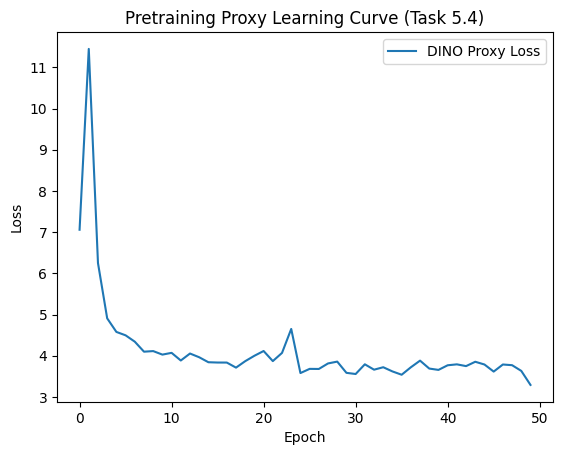

In [5]:
class DINOLoss(nn.Module):
    def __init__(self, out_dim=65536):
        super().__init__()
        self.register_buffer("center", torch.zeros(1, out_dim))
    def forward(self, s_out, t_out):
        s_p = [F.log_softmax(s / 0.1, dim=-1) for s in s_out]
        t_p = [F.softmax((t - self.center) / 0.04, dim=-1) for t in t_out]
        loss = 0
        for t_idx, t in enumerate(t_p):
            for s_idx, s in enumerate(s_p):
                if t_idx != s_idx: loss -= torch.mean(torch.sum(t * s, dim=-1))
        self.center = self.center * 0.9 + torch.cat(t_out).mean(dim=0, keepdim=True) * 0.1
        return loss / (len(s_p) * len(t_p))

gc.collect(); torch.cuda.empty_cache()
criterion = DINOLoss().to(device)
scaler = torch.amp.GradScaler('cuda')
pretrain_losses = []

def run_pretraining(epochs=50):
    model.train()
    start_time = time.time()
    
    parallel_model = nn.DataParallel(model) if torch.cuda.device_count() > 1 else model

    for epoch in range(epochs):
        epoch_loss = 0
        for views in train_loader_ssl:
            views = [v.to(device, non_blocking=True) for v in views]
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                s_out, t_out = parallel_model(views)
                loss = criterion(s_out, t_out)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            with torch.no_grad():
                for s_p, t_p in zip(model.student_backbone.parameters(), model.teacher_backbone.parameters()):
                    t_p.data.lerp_(s_p.data, 0.01) # Fast EMA
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss/len(train_loader_ssl)
        pretrain_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")
        
    print(f"Pretraining Time: {time.time()-start_time:.2f}s")
    torch.save(model.student_backbone.state_dict(), 'dino_encoder.pth')

run_pretraining(epochs=50)

plt.plot(pretrain_losses, label='DINO Proxy Loss')
plt.title("Pretraining Proxy Learning Curve (Task 5.4)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

In [8]:
macs, params = get_model_complexity_info(model.student_backbone, (3, 224, 224), as_strings=True, print_per_layer_stat=False)
print(f"ViT-Base Backbone -> GFLOPs: {macs} | Parameters: {params}")

def get_features(path):
    tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    ds = datasets.ImageFolder(root=path, transform=tf)
    ld = DataLoader(ds, batch_size=32, shuffle=False, num_workers=4)
    model.student_backbone.eval()
    feats, lbls = [], []
    with torch.no_grad():
        for img, lbl in ld:
            feats.append(model.student_backbone(img.to(device)).cpu().numpy())
            lbls.append(lbl.numpy())
    return np.concatenate(feats), np.concatenate(lbls), ds.classes

print("Extracting Frozen Features...")
x_train, y_train, class_names = get_features(TRAIN_PATH)
x_test, y_test, _ = get_features(TEST_PATH)

ViT-Base Backbone -> GFLOPs: 12.02 GMac | Parameters: 85.8 M
Extracting Frozen Features...


In [6]:
heads = {
    "Linear Probe": LogisticRegression(max_iter=2000),
    "Shallow MLP": MLPClassifier(hidden_layer_sizes=(512,), max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

print("--- Downstream Evaluation (Frozen Features) ---")
head_results = {}
for name, head in heads.items():
    t0 = time.time()
    head.fit(x_train, y_train)
    train_time = time.time() - t0
    
    t1 = time.time()
    acc = head.score(x_test, y_test)
    test_time = time.time() - t1
    
    head_results[name] = acc
    print(f"{name:15} | Acc: {acc:.4f} | Train Time: {train_time:.2f}s | Test Time: {test_time:.2f}s")

--- Downstream Evaluation (Frozen Features) ---


NameError: name 'x_train' is not defined

In [ ]:
ft_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(class_names))
ft_model.load_state_dict(torch.load('dino_encoder.pth'), strict=False)
ft_model.to(device)

ft_optim = torch.optim.AdamW(ft_model.parameters(), lr=1e-5)
criterion_ft = nn.CrossEntropyLoss()

tf_ft = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
train_loader_ft = DataLoader(datasets.ImageFolder(TRAIN_PATH, tf_ft), batch_size=16, shuffle=True)
test_loader_ft = DataLoader(datasets.ImageFolder(TEST_PATH, tf_ft), batch_size=16, shuffle=False)

ft_losses = []
print("\n--- Starting Full Fine-Tuning ---")
for epoch in range(10): 
    ft_model.train()
    epoch_loss = 0
    for imgs, lbls in train_loader_ft:
        imgs, lbls = imgs.to(device), lbls.to(device)
        ft_optim.zero_grad()
        loss = criterion_ft(ft_model(imgs), lbls)
        loss.backward()
        ft_optim.step()
        epoch_loss += loss.item()
    ft_losses.append(epoch_loss/len(train_loader_ft))

plt.plot(ft_losses, color='orange', label='Fine-tuning Loss')
plt.title("Downstream Fine-tuning Learning Curve (Task 5.4)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

ft_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader_ft:
        outputs = ft_model(imgs.to(device))
        _, pred = torch.max(outputs, 1)
        total += lbls.size(0)
        correct += (pred == lbls.to(device)).sum().item()

ft_acc = correct / total
print(f"Linear Probe Accuracy: {head_results['Linear Probe']:.4f}")
print(f"Full Fine-Tuning Accuracy: {ft_acc:.4f}")

In [ ]:
lp = heads["Linear Probe"]
y_pred = lp.predict(x_test)
y_prob = lp.predict_proba(x_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix (Linear Probe)")
plt.show()

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
plt.figure(figsize=(7,5))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_prob[:, i]):.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (Task 5.4)')
plt.legend(loc="lower right")
plt.show()

print(f"Overall ROC-AUC (OVR): {roc_auc_score(y_test, y_prob, multi_class='ovr'):.4f}")

In [ ]:
print("--- k-NN Accuracy ---")
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(x_train, y_train)
    print(f"{k}-NN: {knn.score(x_test, y_test):.4f}")

fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
eff_acc = []
for f in fractions:
    n_samples = max(1, int(f * len(x_train)))
    idx = np.random.choice(len(x_train), n_samples, replace=False)
    clf = LogisticRegression(max_iter=2000).fit(x_train[idx], y_train[idx])
    eff_acc.append(clf.score(x_test, y_test))

plt.plot([f*100 for f in fractions], eff_acc, marker='o', color='purple')
plt.title("Label-Efficiency Curve (Task 5.4)")
plt.xlabel("Percentage of Labeled Data (%)"); plt.ylabel("Linear Probe Accuracy")
plt.grid(True); plt.show()

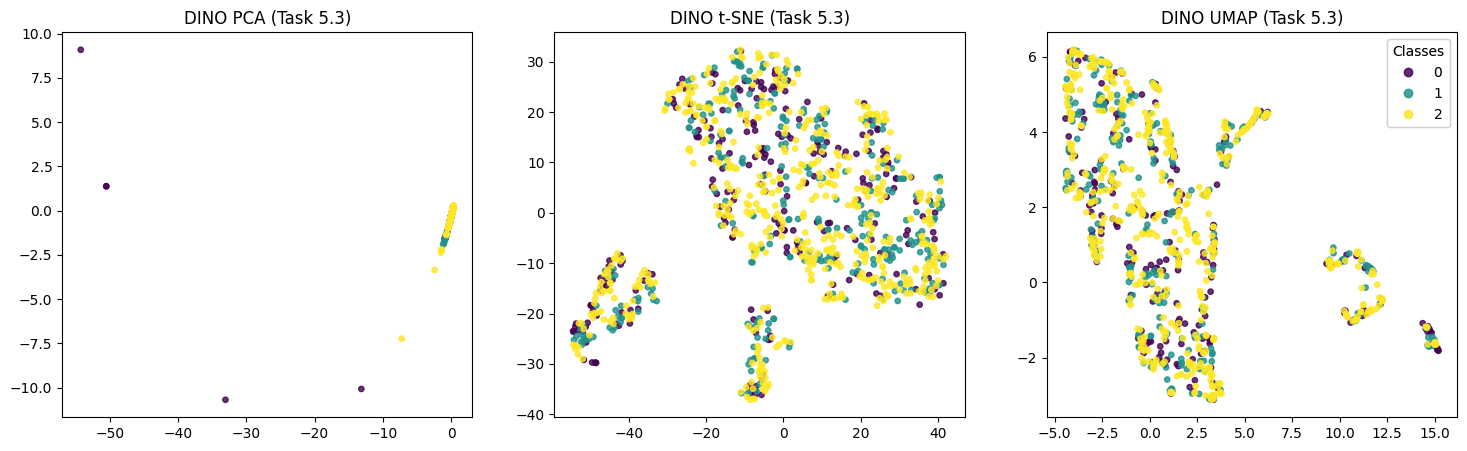

Silhouette Score (Separation Metric): -0.1521


In [26]:
pca_emb = PCA(n_components=2).fit_transform(x_test)
tsne_emb = TSNE(n_components=2, perplexity=30).fit_transform(x_test)
umap_emb = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(x_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['PCA', 't-SNE', 'UMAP']
embs = [pca_emb, tsne_emb, umap_emb]

for ax, emb, title in zip(axes, embs, titles):
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=y_test, cmap='viridis', s=15, alpha=0.8)
    ax.set_title(f"DINO {title} (Task 5.3)")
    if title == 'UMAP': 
        legend = ax.legend(*scatter.legend_elements(), title="Classes")
        ax.add_artist(legend)
plt.show()

sil_score = silhouette_score(x_test, y_test)
print(f"Silhouette Score (Separation Metric): {sil_score:.4f}")